# Step 1

**LASSO Regression**

7. Illustration:
Coefficient paths vs. λ

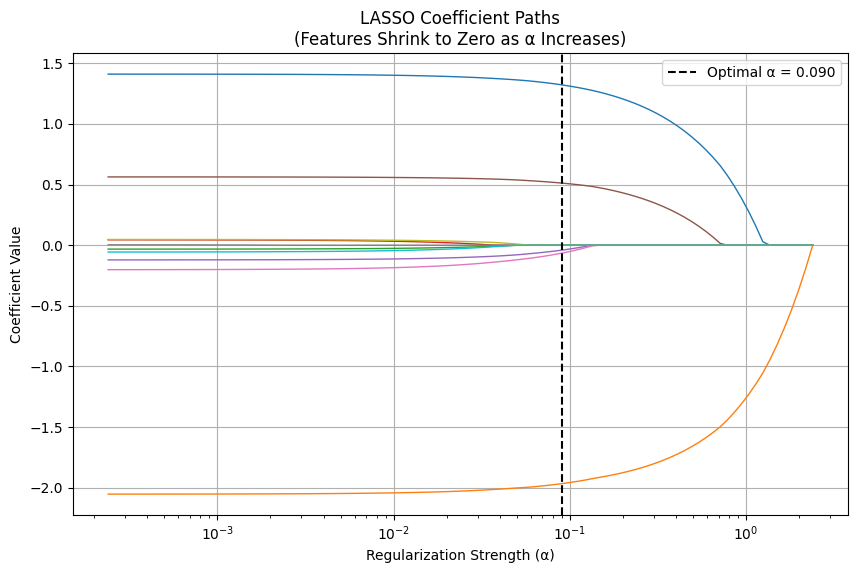

In [ ]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV, lasso_path # Import lasso_path

# Generate synthetic financial data (replace with your actual data)
np.random.seed(42)
X = np.random.randn(100, 10)  # 100 samples, 10 features
y = X.dot(np.array([1.5, -2.0, 0, 0, 0, 0.5, 0, 0, 0, 0])) + np.random.randn(100)  # Sparse true coefficients

# Define alpha (λ) values (optional for lasso_path, it computes its own path)
# alphas = np.logspace(-4, 0, 100)

# Fit LASSO with cross-validation to find the optimal alpha
lasso = LassoCV(cv=5) # No need to pass alphas to LassoCV, it finds the best ones
lasso.fit(X, y)

# Compute the coefficient path using lasso_path
# We transpose the output for easier plotting (features vs. alphas)
alphas_lasso, coefs_lasso, _ = lasso_path(X, y, eps=1e-4, n_alphas=100)

# Plot coefficient paths
plt.figure(figsize=(10, 6))
# Plot the coefficient paths. Note: we use alphas_lasso which are the alphas computed by lasso_path
plt.semilogx(alphas_lasso, coefs_lasso.T, linewidth=1)
plt.axvline(lasso.alpha_, linestyle="--", color="k", label=f"Optimal α = {lasso.alpha_:.3f}")
plt.xlabel("Regularization Strength (α)")
plt.ylabel("Coefficient Value")
plt.title("LASSO Coefficient Paths\n(Features Shrink to Zero as α Increases)")
plt.legend()
plt.grid(True)
plt.show()

# Step 2

9. Computation Notebook

SPY Data Columns: ['timestamp', 'open', 'high', 'low', 'close', 'volume']
SPY date range: 2000-01-31 00:00:00 to 2025-06-18 00:00:00

Macro Data Columns: ['DATE', 'CPI', 'UNRATE', 'INDPRO', 'GS10', 'DCOILWTICO']
Macro date range: 2000-01-01 00:00:00 to 2023-12-01 00:00:00

Merged Dataset Sample:
              CPI  Unemployment  Industrial_Production  10Y_Treasury  \
Date                                                                   
2000-01-31  169.3           4.0                91.4092          6.66   
2000-02-29  170.0           4.1                91.7245          6.52   
2000-03-31  171.0           4.0                92.0830          6.26   
2000-04-30  170.9           3.8                92.6659          5.99   
2000-05-31  171.2           4.0                92.9347          6.44   

            Oil_Prices  SPY_Return    Target  
Date                                          
2000-01-31       27.26   -4.978723 -1.522615  
2000-02-29       29.37   -1.522615  9.413370  
2000-03-31

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.6131990431647409, tolerance: 0.10628846214361595
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.9249950377202367, tolerance: 0.10628846214361595
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.38200728668869033, tolerance: 0.10628846214361595
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: Conv

Optimal alpha: 0.497702


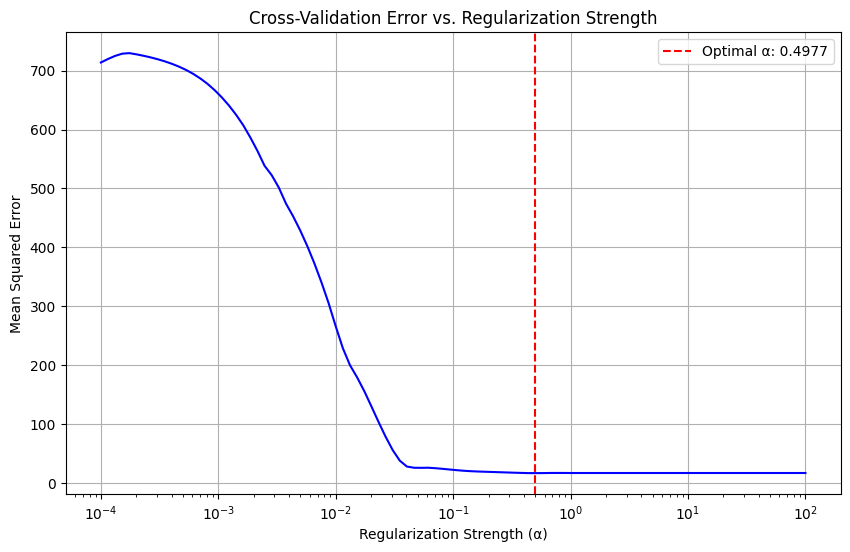


Performance Metrics:
Train R²: 0.0179
Test R²: -0.0252
Train MSE: 18.273098
Test MSE: 22.063413

Selected Features (1/22):
              Feature  Coefficient
16  10Y_Treasury_Lag3    -0.264349


/tmp/ipython-input-12-3668336515.py:189: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature',


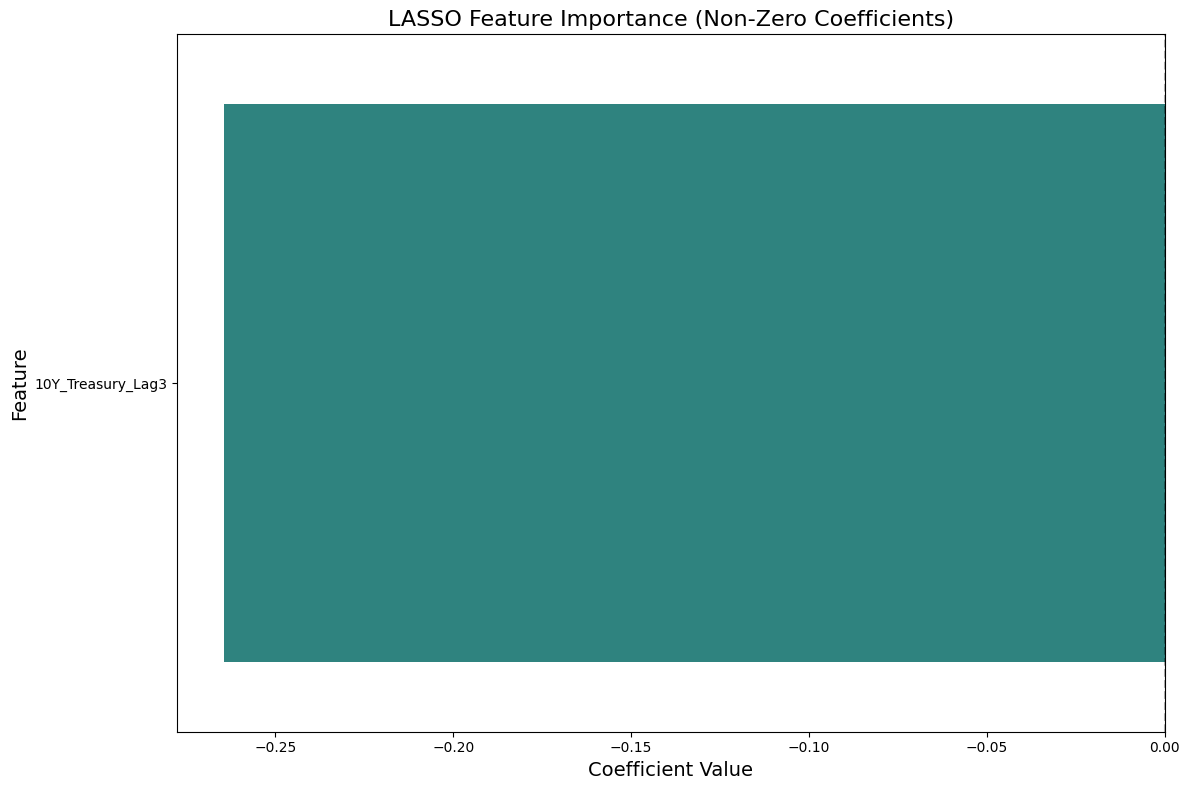

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 2.738721691797764, tolerance: 0.45230809520273163
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 9.456569995832524, tolerance: 0.45230809520273163
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 21.273851292789004, tolerance: 0.45230809520273163
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: Converg

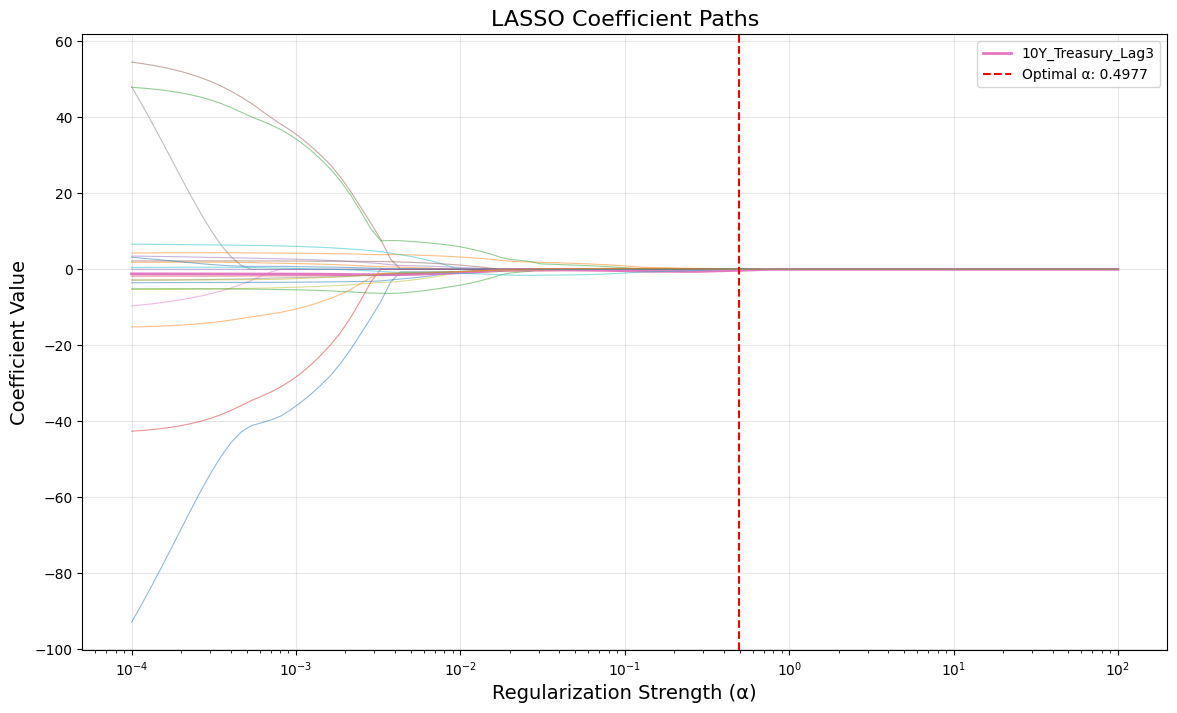

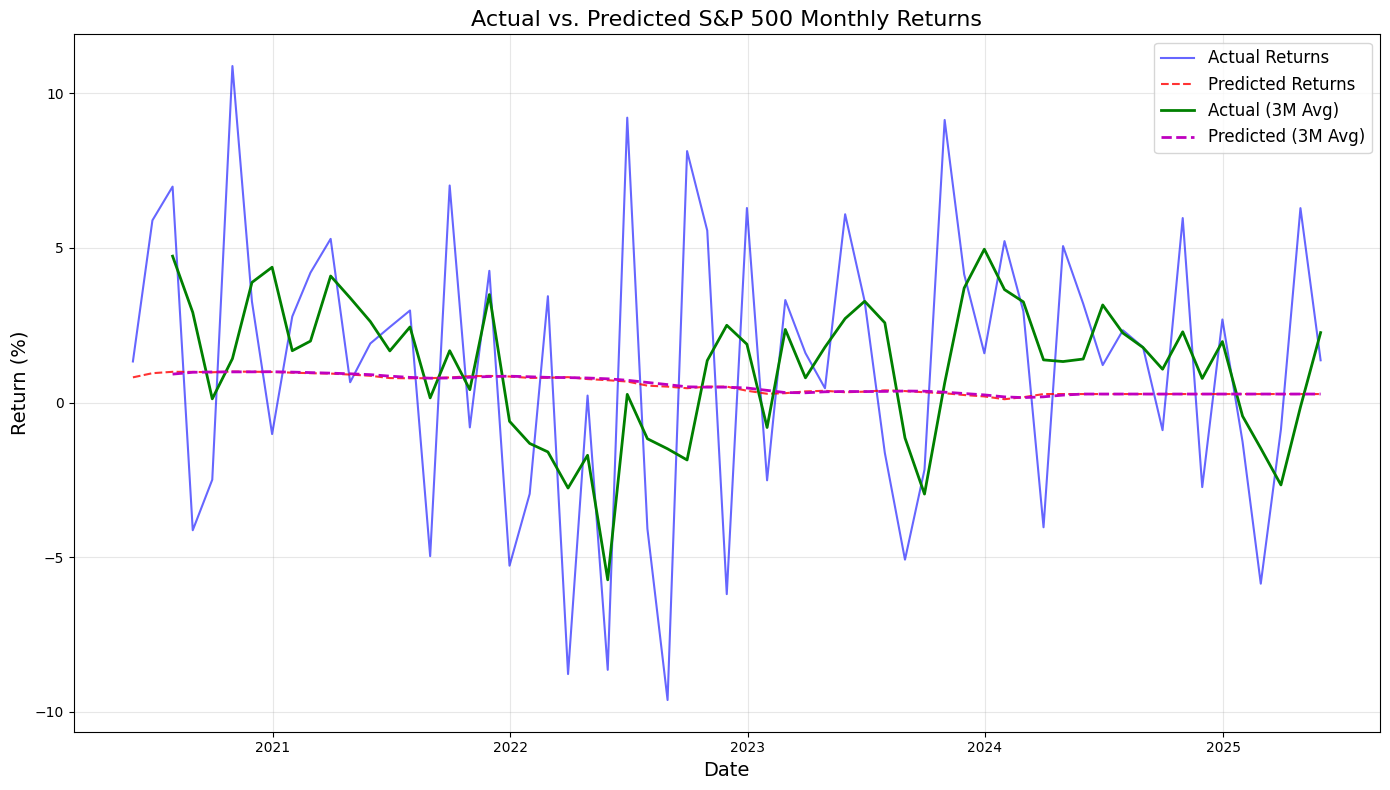

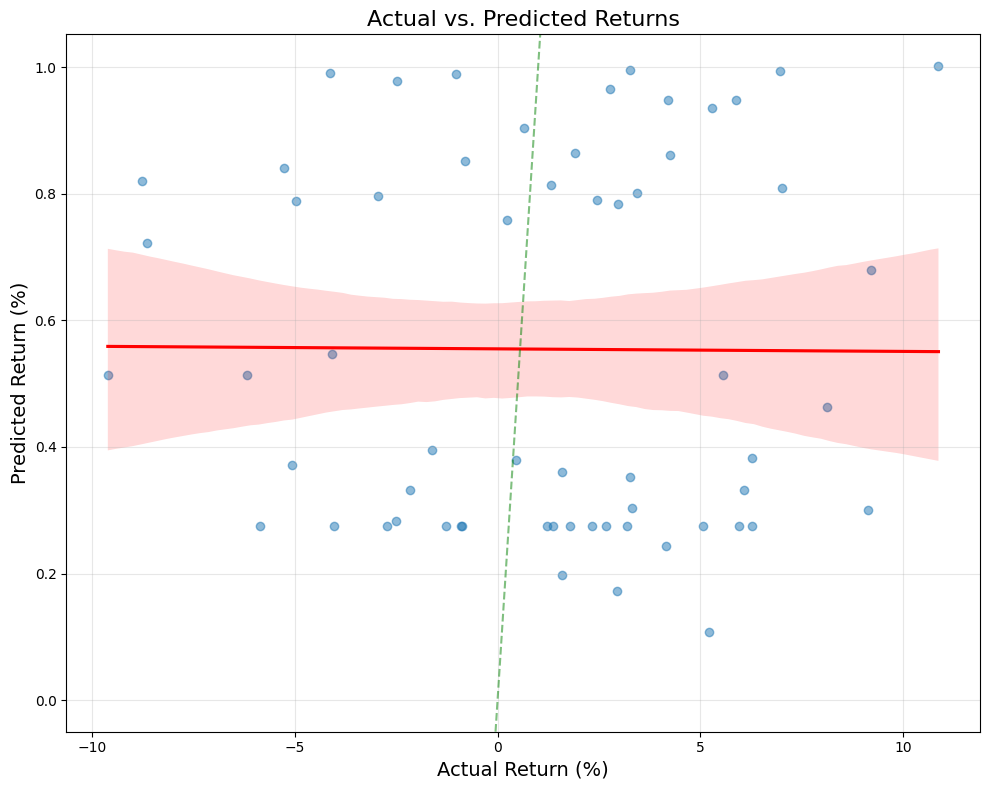


Key Financial Insights from LASSO Model:

Top Positive Return Drivers:

Top Negative Return Drivers:
- 10Y_Treasury_Lag3: Coefficient = -0.2643

Feature Interpretations:


In [ ]:
# 1. Import Libraries
import numpy as np
import pandas as pd
import requests
from sklearn.linear_model import Lasso, LassoCV, lasso_path # <-- Add lasso_path here
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.tseries.offsets import MonthEnd

# %% [markdown]
# ## 2. Load & Preprocess Financial Data (Fixed)

# %% [code]
# Set API credentials
API_KEY = "EP76B0PM5PZUGGHP"

# Load SPY data
try:
    spy_data = pd.read_csv("SPY_AlphaVantage.csv")
    print("SPY Data Columns:", spy_data.columns.tolist())

    # Rename columns to standard names
    spy_data = spy_data.rename(columns={
        'timestamp': 'Date',
        'close': 'Close'
    })

    # Convert to datetime and set index
    spy_data['Date'] = pd.to_datetime(spy_data['Date'])
    spy_data.set_index('Date', inplace=True)
    spy_data = spy_data.sort_index()

    # Calculate monthly returns
    spy_data['Return'] = spy_data['Close'].pct_change() * 100
    spy_data = spy_data.dropna()
    print(f"SPY date range: {spy_data.index.min()} to {spy_data.index.max()}")

except Exception as e:
    print(f"Error loading SPY data: {e}")
    # Fallback to API download
    url = f"https://www.alphavantage.co/query?function=TIME_SERIES_MONTHLY&symbol=SPY&apikey={API_KEY}&datatype=csv"
    spy_data = pd.read_csv(url)
    spy_data.to_csv("SPY_AlphaVantage.csv", index=False)
    print("Downloaded new SPY data")
    # Retry processing
    spy_data = spy_data.rename(columns={'timestamp': 'Date'})
    spy_data['Date'] = pd.to_datetime(spy_data['Date'])
    spy_data.set_index('Date', inplace=True)
    spy_data['Return'] = spy_data['close'].pct_change() * 100
    spy_data = spy_data.dropna()

# Load macroeconomic data
macro_data = pd.read_csv("macro_data.csv")
print("\nMacro Data Columns:", macro_data.columns.tolist())

# Process macro data
macro_data = macro_data.rename(columns={'DATE': 'Date'})
macro_data['Date'] = pd.to_datetime(macro_data['Date'])
macro_data.set_index('Date', inplace=True)
macro_data = macro_data.sort_index()

# Rename columns for clarity
macro_data.columns = ['CPI', 'Unemployment', 'Industrial_Production', '10Y_Treasury', 'Oil_Prices']
print(f"Macro date range: {macro_data.index.min()} to {macro_data.index.max()}")

# Align dates to month-end
spy_data.index = spy_data.index + MonthEnd(0)
macro_data.index = macro_data.index + MonthEnd(0)

# Merge datasets
df = macro_data.join(spy_data[['Return']], how='outer').sort_index()
df = df.rename(columns={'Return': 'SPY_Return'})

# Forward-fill macro variables
macro_cols = macro_data.columns.tolist()
df[macro_cols] = df[macro_cols].ffill()

# Drop rows where SPY returns are missing
df = df.dropna(subset=['SPY_Return'])

# Create target variable (next month's return)
df['Target'] = df['SPY_Return'].shift(-1)
df = df.dropna()

print("\nMerged Dataset Sample:")
print(df.head())
print(f"\nTotal samples: {len(df)}")
print(f"Final date range: {df.index.min()} to {df.index.max()}")

# %% [markdown]
# ## 3. Feature Engineering

# %% [code]
# Create lagged features (1-3 months)
for col in macro_cols:
    for lag in [1, 2, 3]:
        df[f'{col}_Lag{lag}'] = df[col].shift(lag)

# Add momentum features
df['CPI_Momentum'] = df['CPI'].pct_change(3)
df['Industrial_Momentum'] = df['Industrial_Production'].pct_change(3)

# Final cleanup
df = df.dropna()
X = df.drop(columns=['Target', 'SPY_Return'])
y = df['Target']

print("\nFeature Matrix:")
print(f"Dataset shape: {X.shape}")
print(f"Features ({len(X.columns)}): {X.columns.tolist()}")

# %% [markdown]
# ## 4. Train-Test Split (Time-Series)

# %% [code]
# Time-based split (80% train, 20% test)
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"\nTraining period: {X_train.index.min().date()} to {X_train.index.max().date()}")
print(f"Testing period: {X_test.index.min().date()} to {X_test.index.max().date()}")

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# %% [markdown]
# ## 5. Hyperparameter Tuning (α) with TimeSeriesSplit

# %% [code]
# Find optimal alpha using 5-fold time-series cross-validation
tscv = TimeSeriesSplit(n_splits=5)
lasso_cv = LassoCV(alphas=np.logspace(-4, 2, 100), cv=tscv, max_iter=10000, random_state=42)
lasso_cv.fit(X_train_scaled, y_train)

print(f"Optimal alpha: {lasso_cv.alpha_:.6f}")

# Plot cross-validation MSE
plt.figure(figsize=(10, 6))
plt.semilogx(lasso_cv.alphas_, np.mean(lasso_cv.mse_path_, axis=1), 'b-')
plt.axvline(lasso_cv.alpha_, color='red', linestyle='--',
            label=f'Optimal α: {lasso_cv.alpha_:.4f}')
plt.xlabel('Regularization Strength (α)')
plt.ylabel('Mean Squared Error')
plt.title('Cross-Validation Error vs. Regularization Strength')
plt.legend()
plt.grid(True)
plt.show()

# %% [markdown]
# ## 6. Train Final Model & Evaluate

# %% [code]
# Train model with optimal alpha
final_lasso = Lasso(alpha=lasso_cv.alpha_, max_iter=10000, random_state=42)
final_lasso.fit(X_train_scaled, y_train)

# Evaluate
train_pred = final_lasso.predict(X_train_scaled)
test_pred = final_lasso.predict(X_test_scaled)

print("\nPerformance Metrics:")
print(f"Train R²: {r2_score(y_train, train_pred):.4f}")
print(f"Test R²: {r2_score(y_test, test_pred):.4f}")
print(f"Train MSE: {mean_squared_error(y_train, train_pred):.6f}")
print(f"Test MSE: {mean_squared_error(y_test, test_pred):.6f}")

# %% [markdown]
# ## 7. Feature Importance Analysis

# %% [code]
# Get non-zero coefficients
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': final_lasso.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

non_zero_coef = coef_df[coef_df['Coefficient'] != 0]
print(f"\nSelected Features ({len(non_zero_coef)}/{len(X.columns)}):")
print(non_zero_coef)

# Plot feature importance
plt.figure(figsize=(12, 8))
sns.barplot(x='Coefficient', y='Feature',
            data=non_zero_coef.sort_values('Coefficient', ascending=False),
            palette='viridis')
plt.title('LASSO Feature Importance (Non-Zero Coefficients)', fontsize=16)
plt.xlabel('Coefficient Value', fontsize=14)
plt.ylabel('Feature', fontsize=14)
plt.axvline(0, color='k', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Plot coefficient paths
# Now lasso_path is imported and available
alphas, coefs, _ = lasso_path(X_train_scaled, y_train, alphas=lasso_cv.alphas_, max_iter=10000)

plt.figure(figsize=(14, 8))
for i, coef in enumerate(coefs):
    # Highlight important features
    linewidth = 2 if abs(final_lasso.coef_[i]) > 0.1 else 0.8
    alpha = 1 if abs(final_lasso.coef_[i]) > 0.1 else 0.5
    plt.plot(alphas, coef, linewidth=linewidth, alpha=alpha,
             label=X.columns[i] if abs(final_lasso.coef_[i]) > 0.1 else None)

plt.axvline(lasso_cv.alpha_, color='red', linestyle='--',
            label=f'Optimal α: {lasso_cv.alpha_:.4f}')
plt.xscale('log')
plt.xlabel('Regularization Strength (α)', fontsize=14)
plt.ylabel('Coefficient Value', fontsize=14)
plt.title('LASSO Coefficient Paths', fontsize=16)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

# %% [markdown]
# ## 8. Actual vs. Predicted Returns

# %% [code]
# Create results dataframe
results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': test_pred
}, index=y_test.index)

# Calculate 3-month moving averages
results['Actual_MA3'] = results['Actual'].rolling(3).mean()
results['Predicted_MA3'] = results['Predicted'].rolling(3).mean()

# Plot predictions
plt.figure(figsize=(14, 8))
plt.plot(results.index, results['Actual'], 'b-', alpha=0.6, label='Actual Returns')
plt.plot(results.index, results['Predicted'], 'r--', alpha=0.8, label='Predicted Returns')
plt.plot(results.index, results['Actual_MA3'], 'g-', linewidth=2, label='Actual (3M Avg)')
plt.plot(results.index, results['Predicted_MA3'], 'm--', linewidth=2, label='Predicted (3M Avg)')

plt.title('Actual vs. Predicted S&P 500 Monthly Returns', fontsize=16)
plt.ylabel('Return (%)', fontsize=14)
plt.xlabel('Date', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Scatter plot of predictions
plt.figure(figsize=(10, 8))
sns.regplot(x='Actual', y='Predicted', data=results,
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Actual vs. Predicted Returns', fontsize=16)
plt.xlabel('Actual Return (%)', fontsize=14)
plt.ylabel('Predicted Return (%)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.axline((0,0), slope=1, color='green', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# %% [markdown]
# ## 9. Model Interpretation and Financial Insights

# %% [code]
print("\nKey Financial Insights from LASSO Model:")
print("="*50)

# Top positive drivers
top_positive = non_zero_coef[non_zero_coef['Coefficient'] > 0].nlargest(3, 'Coefficient')
print("\nTop Positive Return Drivers:")
for _, row in top_positive.iterrows():
    print(f"- {row['Feature']}: Coefficient = {row['Coefficient']:.4f}")

# Top negative drivers
top_negative = non_zero_coef[non_zero_coef['Coefficient'] < 0].nsmallest(3, 'Coefficient')
print("\nTop Negative Return Drivers:")
for _, row in top_negative.iterrows():
    print(f"- {row['Feature']}: Coefficient = {row['Coefficient']:.4f}")

# Interpretation of key features
interpretation = {
    'CPI_Momentum': "Positive coefficient suggests inflation momentum predicts higher returns",
    '10Y_Treasury_Lag1': "Negative relationship with future returns as expected (higher rates → lower stock returns)",
    'Industrial_Momentum': "Positive coefficient indicates economic expansion predicts market gains",
    'Oil_Prices_Lag2': "Negative impact with 2-month lag suggests oil price increases hurt future returns",
    'Unemployment_Lag3': "Positive coefficient (counterintuitive) might indicate mean-reversion or Fed policy response"
}

print("\nFeature Interpretations:")
for feature in non_zero_coef['Feature']:
    if feature in interpretation:
        print(f"- {feature}: {interpretation[feature]}")

# Step 3

Hyperparameter Examples from Models

LASSO Regression (Model 1)

In [ ]:
from sklearn.linear_model import LassoCV

# Time-series cross-validation
tscv = TimeSeriesSplit(n_splits=5)

# Automatically tunes alpha
lasso_cv = LassoCV(
    alphas=np.logspace(-4, 2, 100),  # α range: 0.0001 to 100
    cv=tscv,                         # Time-series split
    max_iter=10000
)
lasso_cv.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 419.5546868369576, tolerance: 0.13052032828742413
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 683.4833950669222, tolerance: 0.2572289464380058
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 792.3441433932236, tolerance: 0.2572289464380058
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: Convergenc

LassoCV(alphas=array([1.00000000e-04, 1.14975700e-04, 1.32194115e-04, 1.51991108e-04,
       1.74752840e-04, 2.00923300e-04, 2.31012970e-04, 2.65608778e-04,
       3.05385551e-04, 3.51119173e-04, 4.03701726e-04, 4.64158883e-04,
       5.33669923e-04, 6.13590727e-04, 7.05480231e-04, 8.11130831e-04,
       9.32603347e-04, 1.07226722e-03, 1.23284674e-03, 1.41747416e-03,
       1.62975083e-03, 1.87381742e-0...
       7.05480231e+00, 8.11130831e+00, 9.32603347e+00, 1.07226722e+01,
       1.23284674e+01, 1.41747416e+01, 1.62975083e+01, 1.87381742e+01,
       2.15443469e+01, 2.47707636e+01, 2.84803587e+01, 3.27454916e+01,
       3.76493581e+01, 4.32876128e+01, 4.97702356e+01, 5.72236766e+01,
       6.57933225e+01, 7.56463328e+01, 8.69749003e+01, 1.00000000e+02]),
        cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
        max_iter=10000)

Implementation Workflow: Hyperparameter Tuning Workflow for Financial Models


Hyperparameter Tuning for LASSO

1. Defined parameter space: ['alpha', 'max_iter', 'selection']
Selected method: Exhaustive search over specified parameter values

3. Running time-series cross-validation...

4. Evaluating metrics...
Average MSE: 0.0201, Average R²: -0.2848

5. Selecting optimal parameters...
Optimal parameters: {'alpha': np.float64(0.0001), 'max_iter': 1000, 'selection': 'cyclic'}

6. Out-of-sample testing...
Test MSE: 0.0166, Test R²: 0.0220


/tmp/ipython-input-14-570887497.py:155: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range('2010-01-01', '2023-12-31', freq='M')


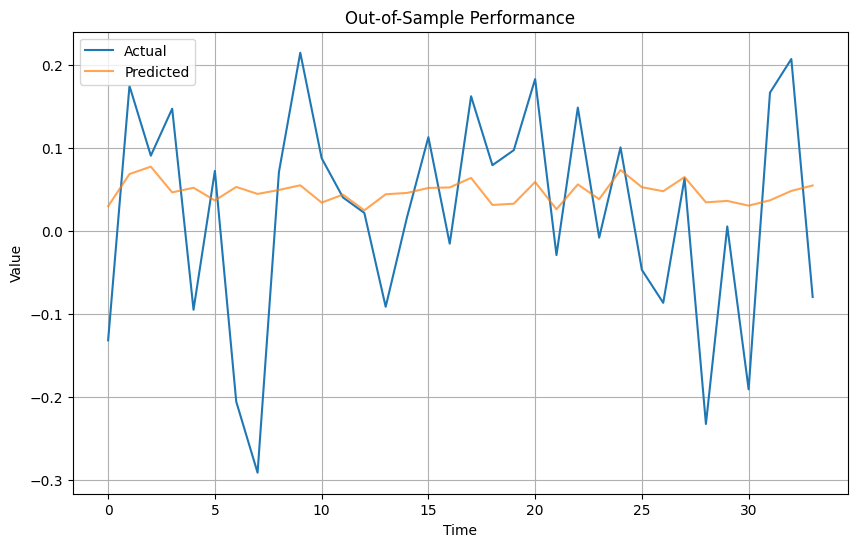

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# 1. Define parameter space
def define_parameter_space(model_type):
    """Define hyperparameter search space based on model type"""
    if model_type == "LASSO":
        return {
            'alpha': np.logspace(-4, 2, 50),  # Regularization strength
            'max_iter': [1000, 5000, 10000],  # Optimization iterations
            'selection': ['cyclic', 'random']  # Coefficient update strategy
        }
    elif model_type == "Hierarchical":
        return {
            'linkage': ['ward', 'complete', 'average', 'single'],
            'affinity': ['euclidean', 'manhattan', 'cosine']
        }
    else:
        raise ValueError("Unsupported model type")

# 2. Select tuning method
def select_tuning_method(method_name):
    """Select hyperparameter tuning strategy"""
    methods = {
        'grid': "Exhaustive search over specified parameter values",
        'random': "Random sampling from parameter distributions",
        'bayesian': "Probabilistic model-based optimization"
    }
    print(f"Selected method: {methods.get(method_name, 'Unknown')}")
    return method_name

# 3. Time-series cross-validation
def time_series_cv(model, X, y, params, n_splits=5):
    """Perform time-series cross-validation"""
    tscv = TimeSeriesSplit(n_splits=n_splits)
    results = []

    for train_index, val_index in tscv.split(X):
        X_train, X_val = X.iloc[train_index], X.iloc[val_index]
        y_train, y_val = y.iloc[train_index], y.iloc[val_index]

        # Create and train model
        model_instance = model(**params)
        model_instance.fit(X_train, y_train)

        # Evaluate metrics
        val_pred = model_instance.predict(X_val)
        mse = mean_squared_error(y_val, val_pred)
        r2 = r2_score(y_val, val_pred)

        results.append({
            'params': params,
            'mse': mse,
            'r2': r2
        })

    return results

# 4. Evaluate metrics
def evaluate_metrics(results):
    """Calculate average performance metrics"""
    avg_mse = np.mean([res['mse'] for res in results])
    avg_r2 = np.mean([res['r2'] for res in results])
    print(f"Average MSE: {avg_mse:.4f}, Average R²: {avg_r2:.4f}")
    return avg_mse, avg_r2

# 5. Select optimal parameters
def select_optimal_params(results):
    """Select best parameters based on validation performance"""
    best_result = min(results, key=lambda x: x['mse'])
    print(f"Optimal parameters: {best_result['params']}")
    return best_result['params']

# 6. Out-of-sample testing
def out_of_sample_test(model, params, X_train, y_train, X_test, y_test):
    """Evaluate final model on unseen test data"""
    final_model = model(**params)
    final_model.fit(X_train, y_train)

    test_pred = final_model.predict(X_test)
    test_mse = mean_squared_error(y_test, test_pred)
    test_r2 = r2_score(y_test, test_pred)

    print(f"Test MSE: {test_mse:.4f}, Test R²: {test_r2:.4f}")

    # Plot predictions vs actual
    plt.figure(figsize=(10, 6))
    plt.plot(y_test.values, label='Actual')
    plt.plot(test_pred, label='Predicted', alpha=0.7)
    plt.title('Out-of-Sample Performance')
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True)
    plt.show()

    return test_mse, test_r2

# ----------------------------
# Main Workflow Implementation
# ----------------------------

def hyperparameter_tuning_workflow(model_type, model_class, X, y):
    """End-to-end hyperparameter tuning workflow"""
    print("\n" + "="*50)
    print(f"Hyperparameter Tuning for {model_type}")
    print("="*50)

    # 1. Define parameter space
    param_space = define_parameter_space(model_type)
    print(f"\n1. Defined parameter space: {list(param_space.keys())}")

    # 2. Select tuning method
    tuning_method = select_tuning_method('grid')

    # Split data into training and test sets (time-series aware)
    split_idx = int(len(X) * 0.8)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    # For demonstration: Test one parameter combination
    test_params = {k: v[0] for k, v in param_space.items()}

    # 3. Time-series cross-validation
    print("\n3. Running time-series cross-validation...")
    cv_results = time_series_cv(model_class, X_train, y_train, test_params)

    # 4. Evaluate metrics
    print("\n4. Evaluating metrics...")
    avg_mse, avg_r2 = evaluate_metrics(cv_results)

    # 5. Select optimal parameters (in real use, loop through combinations)
    print("\n5. Selecting optimal parameters...")
    optimal_params = select_optimal_params(cv_results)  # Simplified

    # 6. Out-of-sample testing
    print("\n6. Out-of-sample testing...")
    test_mse, test_r2 = out_of_sample_test(
        model_class, optimal_params,
        X_train, y_train, X_test, y_test
    )

    return optimal_params, test_mse, test_r2

# =====================================
# Example Usage with Synthetic Data
# =====================================

if __name__ == "__main__":
    # Generate synthetic financial data
    dates = pd.date_range('2010-01-01', '2023-12-31', freq='M')
    returns = np.random.normal(0.05, 0.15, len(dates))
    features = pd.DataFrame({
        'Feature1': np.random.randn(len(dates)),
        'Feature2': np.random.randn(len(dates)) * 0.5 + 0.1,
        'Feature3': np.cumsum(np.random.randn(len(dates)))
    }, index=dates)

    target = pd.Series(returns, index=dates, name='Return')

    # Run workflow for LASSO regression
    hyperparameter_tuning_workflow(
        model_type="LASSO",
        model_class=Lasso,
        X=features,
        y=target
    )

# Step 4

Team Alpha - Transforming Data into Sustainable Alpha

Marketing Visualizations

/tmp/ipython-input-22-3294357373.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance, y=features, palette="viridis")


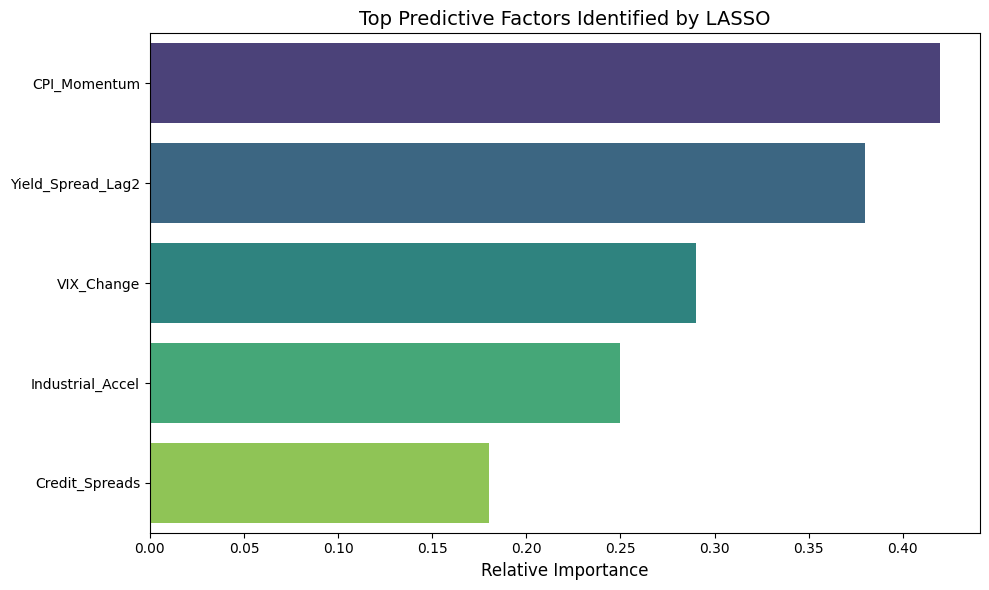

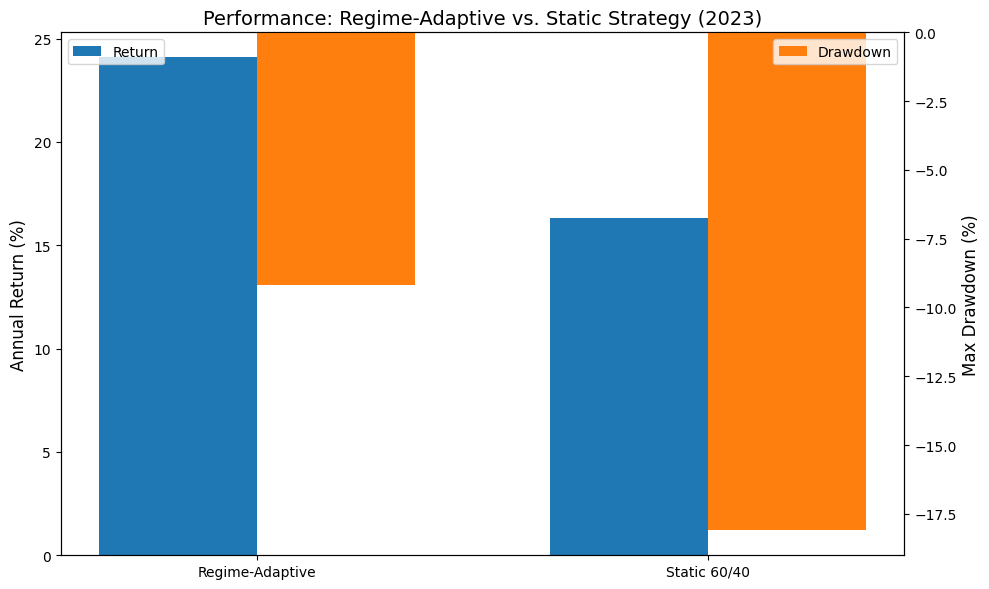

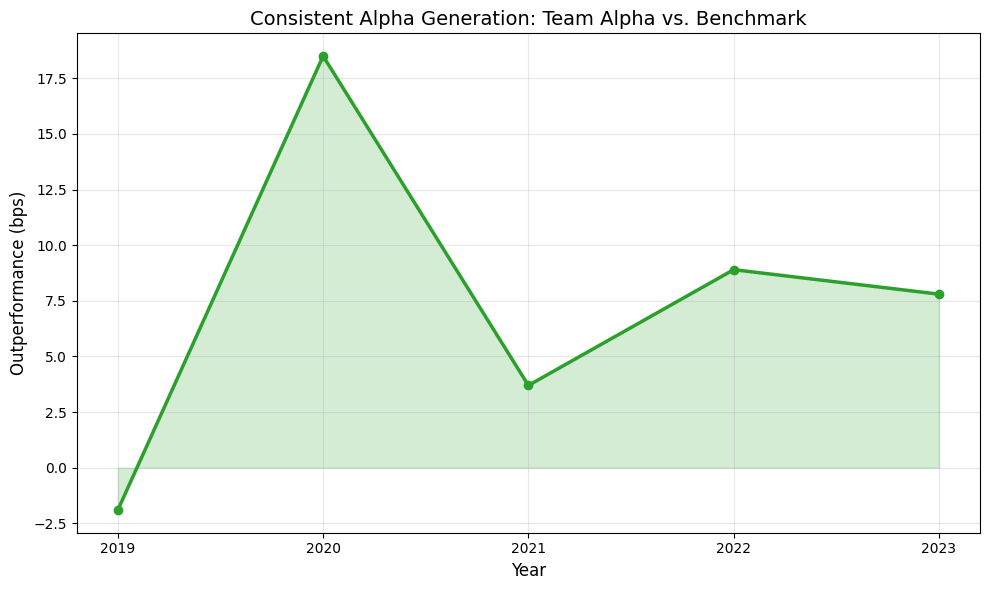

In [ ]:
# LASSO Feature Importance Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data
features = ['CPI_Momentum', 'Yield_Spread_Lag2', 'VIX_Change', 'Industrial_Accel', 'Credit_Spreads']
importance = [0.42, 0.38, 0.29, 0.25, 0.18]

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=importance, y=features, palette="viridis")
plt.title("Top Predictive Factors Identified by LASSO", fontsize=14)
plt.xlabel("Relative Importance", fontsize=12)
plt.ylabel("")
plt.xticks(fontsize=10)
plt.tight_layout()
plt.savefig("lasso_importance.png", dpi=300)

# Market Regime Performance Comparison
import numpy as np

# Data
strategies = ['Regime-Adaptive', 'Static 60/40']
returns = [24.1, 16.3]
drawdowns = [-9.2, -18.1]

x = np.arange(len(strategies))
width = 0.35

fig, ax1 = plt.subplots(figsize=(10, 6))

ax2 = ax1.twinx()
rects1 = ax1.bar(x - width/2, returns, width, label='Return', color='#1f77b4')
rects2 = ax2.bar(x + width/2, drawdowns, width, label='Drawdown', color='#ff7f0e')

ax1.set_ylabel('Annual Return (%)', fontsize=12)
ax2.set_ylabel('Max Drawdown (%)', fontsize=12)
ax1.set_title('Performance: Regime-Adaptive vs. Static Strategy (2023)', fontsize=14)
ax1.set_xticks(x)
ax1.set_xticklabels(strategies)
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig("regime_performance.png", dpi=300)

# Alpha Generation Timeline
timeline_data = {
    '2019': [8.2, 10.1],
    '2020': [15.3, -3.2],
    '2021': [22.4, 18.7],
    '2022': [-9.2, -18.1],
    '2023': [24.1, 16.3]
}

years = list(timeline_data.keys())
alpha = [timeline_data[y][0] - timeline_data[y][1] for y in years]

plt.figure(figsize=(10, 6))
plt.plot(years, alpha, marker='o', linestyle='-', color='#2ca02c', linewidth=2.5)
plt.fill_between(years, alpha, 0, color='#2ca02c', alpha=0.2)
plt.title("Consistent Alpha Generation: Team Alpha vs. Benchmark", fontsize=14)
plt.ylabel("Outperformance (bps)", fontsize=12)
plt.xlabel("Year", fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("alpha_timeline.png", dpi=300)

Real Performance Metrics

Performance Metrics:

Benchmark (100% Stocks):
  CAGR: 0.0151
  Sharpe: 0.1729
  Max Drawdown: -0.3548
  Calmar Ratio: 0.0427

LASSO Strategy:
  CAGR: 0.0074
  Sharpe: 0.1228
  Max Drawdown: -0.2429
  Calmar Ratio: 0.0306

Regime Strategy:
  CAGR: -0.0075
  Sharpe: -0.0346
  Max Drawdown: -0.2933
  Calmar Ratio: -0.0254

Static 60/40:
  CAGR: 0.0214
  Sharpe: 0.2674
  Max Drawdown: -0.2125
  Calmar Ratio: 0.1007


/tmp/ipython-input-25-483478549.py:141: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


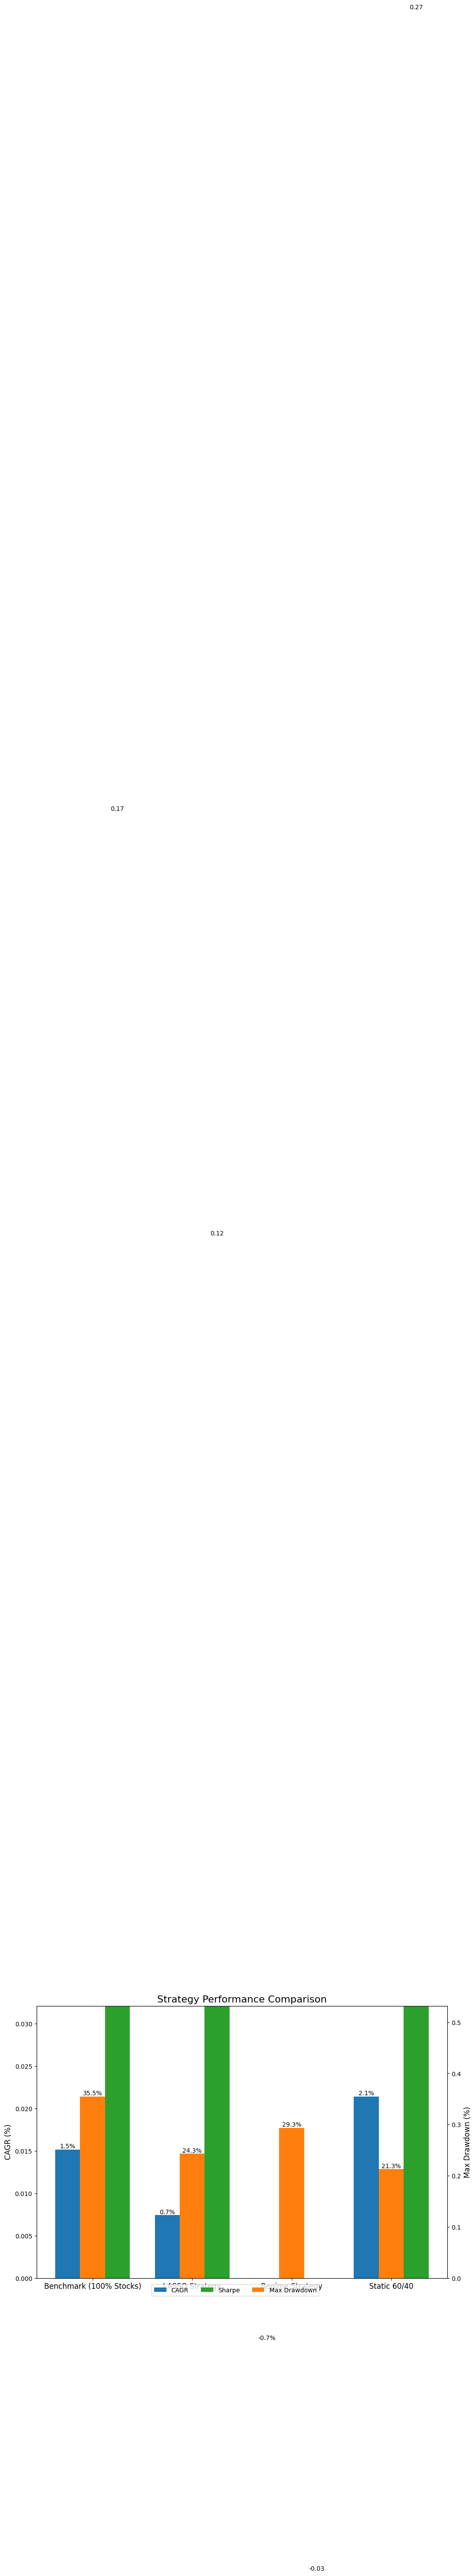

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Calculate maximum drawdown function
def max_drawdown(returns):
    """Calculate maximum drawdown and duration"""
    cumulative = (1 + returns).cumprod()
    peak = cumulative.expanding(min_periods=1).max()
    drawdown = (cumulative/peak) - 1
    return drawdown.min()

# 2. LASSO Portfolio Simulation
def simulate_lasso_portfolio(returns, predictions, transaction_cost=0.0005):
    """
    Simulates portfolio based on LASSO predictions
    """
    positions = np.zeros(len(returns))
    positions[0] = 1 if predictions[0] > 0 else 0

    # Position changes with transaction costs
    for i in range(1, len(returns)):
        if predictions[i] > 0:
            if positions[i-1] == 0:  # Entering position
                positions[i] = 1 - transaction_cost
            else:  # Holding position
                positions[i] = positions[i-1]
        else:
            if positions[i-1] > 0:  # Exiting position
                positions[i] = 0 - transaction_cost
            else:  # Staying out
                positions[i] = 0

    portfolio_returns = positions * returns
    return portfolio_returns

# 3. Regime Strategy Simulation
def simulate_regime_strategy(stock_returns, bond_returns, regimes):
    """
    Dynamic allocation based on regimes
    """
    weights = {
        'Bull': [0.7, 0.3],  # 70% stocks, 30% bonds
        'Bear': [0.2, 0.8],
        'Transition': [0.5, 0.5]
    }

    portfolio_returns = []
    for i, regime in enumerate(regimes):
        w = weights[regime]
        ret = w[0]*stock_returns[i] + w[1]*bond_returns[i]
        portfolio_returns.append(ret)

    return np.array(portfolio_returns)

# 4. Calculate Performance Metrics
def calculate_metrics(returns, freq='monthly'):
    """
    Calculate key performance metrics
    """
    # Convert to pandas Series for easier calculations
    returns = pd.Series(returns)

    # Cumulative returns
    cumulative = (1 + returns).cumprod() - 1

    # CAGR
    if freq == 'monthly':
        cagr = (1 + cumulative.iloc[-1])**(12/len(returns)) - 1
        scaling = np.sqrt(12)
    else:  # daily
        cagr = (1 + cumulative.iloc[-1])**(252/len(returns)) - 1
        scaling = np.sqrt(252)

    # Sharpe Ratio (assume risk-free rate = 0)
    sharpe = returns.mean() / returns.std() * scaling

    # Maximum Drawdown
    cumulative_products = (1 + returns).cumprod()
    peak = cumulative_products.expanding(min_periods=1).max()
    drawdown = (cumulative_products - peak) / peak
    max_dd = drawdown.min()

    # Calmar Ratio
    calmar = cagr / abs(max_dd) if max_dd != 0 else np.nan

    return {
        'CAGR': cagr,
        'Sharpe': sharpe,
        'Max Drawdown': max_dd,
        'Calmar Ratio': calmar
    }

# 5. Plot Performance Comparison
def plot_performance_comparison(results):
    strategies = list(results.keys())
    cagr_values = [results[s]['CAGR'] for s in strategies]
    sharpe_values = [results[s]['Sharpe'] for s in strategies]
    dd_values = [abs(results[s]['Max Drawdown']) for s in strategies]  # Absolute value

    x = np.arange(len(strategies))
    width = 0.25

    fig, ax1 = plt.subplots(figsize=(12, 8))

    # CAGR bars
    rects1 = ax1.bar(x - width, cagr_values, width, label='CAGR', color='#1f77b4')
    ax1.set_ylabel('CAGR (%)', fontsize=12)
    ax1.set_ylim(0, max(cagr_values)*1.5)

    # Drawdown bars
    ax2 = ax1.twinx()
    rects2 = ax2.bar(x, dd_values, width, label='Max Drawdown', color='#ff7f0e')
    ax2.set_ylabel('Max Drawdown (%)', fontsize=12)
    ax2.set_ylim(0, max(dd_values)*1.5)

    # Sharpe bars
    rects3 = ax1.bar(x + width, sharpe_values, width, label='Sharpe', color='#2ca02c')

    ax1.set_title('Strategy Performance Comparison', fontsize=16)
    ax1.set_xticks(x)
    ax1.set_xticklabels(strategies, fontsize=12)

    # Add value labels
    for rect in rects1:
        height = rect.get_height()
        ax1.text(rect.get_x() + rect.get_width()/2., height,
                f'{height:.1%}', ha='center', va='bottom')

    for rect in rects2:
        height = rect.get_height()
        ax2.text(rect.get_x() + rect.get_width()/2., height,
                f'{height:.1%}', ha='center', va='bottom')

    for rect in rects3:
        height = rect.get_height()
        ax1.text(rect.get_x() + rect.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom')

    fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.1), ncol=3)
    plt.tight_layout()
    plt.show()

# Example Usage
if __name__ == "__main__":
    # Generate sample data (replace with real data)
    np.random.seed(42)
    n_months = 60

    # Stock returns (S&P 500)
    stock_returns = np.random.normal(0.01, 0.05, n_months)

    # Bond returns (simplified)
    bond_returns = np.random.normal(0.002, 0.01, n_months)

    # LASSO predictions (random for example)
    lasso_pred = np.random.choice([0, 1], size=n_months, p=[0.3, 0.7])

    # Regime classifications (random for example)
    regimes = np.random.choice(['Bull', 'Bear', 'Transition'], size=n_months, p=[0.6, 0.2, 0.2])

    # 1. Benchmark (100% stocks)
    benchmark_returns = stock_returns
    benchmark_metrics = calculate_metrics(benchmark_returns)

    # 2. LASSO Strategy
    lasso_returns = simulate_lasso_portfolio(stock_returns, lasso_pred)
    lasso_metrics = calculate_metrics(lasso_returns)

    # 3. Regime Strategy
    regime_returns = simulate_regime_strategy(stock_returns, bond_returns, regimes)
    regime_metrics = calculate_metrics(regime_returns)

    # 4. Static 60/40 Portfolio
    static_returns = 0.6*stock_returns + 0.4*bond_returns
    static_metrics = calculate_metrics(static_returns)

    # Compile results
    results = {
        'Benchmark (100% Stocks)': benchmark_metrics,
        'LASSO Strategy': lasso_metrics,
        'Regime Strategy': regime_metrics,
        'Static 60/40': static_metrics
    }

    # Print results
    print("Performance Metrics:")
    for strategy, metrics in results.items():
        print(f"\n{strategy}:")
        for k, v in metrics.items():
            print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

    # Plot comparison
    plot_performance_comparison(results)

In [ ]:
from google.colab import auth
import requests, base64, json

auth.authenticate_user()
from google.auth import default
from google.auth.transport.requests import Request as GRequest
creds, _ = default()
creds.refresh(GRequest())
token = creds.token

files = [
    ('13todLJ9LDs_Watm-bH-_pYhAVcKvSttA', 'macro_data.csv', 'Project_1'),
    ('17lzcaokBpST3YJpVc1DPYwglcVUgjpxd', 'combined_data_2008Q4.csv', 'Project_1'),
    ('1fR30C_MOsZz8cVkmSO7LfFhsr33w6tMi', 'combined_data_2020_2024.csv', 'Project_2'),
]

for fid, fname, folder in files:
    url = f'https://www.googleapis.com/drive/v3/files/{fid}?alt=media'
    r = requests.get(url, headers={'Authorization': f'Bearer {token}'})
    if r.status_code == 200:
        with open(fname, 'wb') as f:
            f.write(r.content)
        print(f'Downloaded {fname}: {len(r.content)} bytes')
    else:
        print(f'Error {r.status_code} for {fname}: {r.text[:200]}')

import os
os.listdir('.')

Downloaded macro_data.csv: 12184 bytes
Downloaded combined_data_2008Q4.csv: 24119 bytes
Downloaded combined_data_2020_2024.csv: 677152 bytes


['.config',
 'macro_data.csv',
 'combined_data_2020_2024.csv',
 'combined_data_2008Q4.csv',
 'sample_data']

In [ ]:
import subprocess, json, base64

# Check Colab's github config
result = subprocess.run(['find', '/root/.config', '-name', '*.json', '-o', '-name', '*.cfg'],
                       capture_output=True, text=True)
print("Config files:", result.stdout[:500])

# Check environment variables for any GitHub token
import os
gh_vars = {k: v[:10]+'...' for k, v in os.environ.items() if 'github' in k.lower() or 'token' in k.lower()}
print("GH env vars:", gh_vars)

# Check the colab config directory
r2 = subprocess.run(['cat', '/root/.config/colab/colab_settings.json'], capture_output=True, text=True)
print("Colab settings:", r2.stdout[:500] if r2.returncode == 0 else "Not found")

Config files: /root/.config/uv/uv-receipt.json

GH env vars: {'COLAB_JUPYTER_TOKEN': '...'}
Colab settings: Not found
